```{index} single: application; portfolio
```
```{index} single: application; investment
```
```{index} single: solver; cbc
```
```{index} single: solver; highs
```
```{index} pandas dataframe
```
```{index} web scraping
```

# MAD portfolio optimization

Portfolio optimization and modern portfolio theory has a long and important history in finance and investment. The principal idea is to find a blend of investments in financial securities that achieves  an optimal trade-off between financial risk and return. The introduction of modern portfolio theory is generally attributed to the 1952 doctoral thesis of [Harry Markowitz](https://en.wikipedia.org/wiki/Harry_Markowitz) who subsequently was award a share of the 1990 Nobel Memorial Prize in Economics for his fundamental contributions to this field. The well-known "Markowitz Model" models measure risk using covariance of the portfolio with respect to constituent assets, then solves a minimum variance problem by quadratic optimization problem subject to constraints to allocate of wealth among assets.

In a [remarkable 1991 paper](https://www.jstor.org/stable/2632458?seq=1), Konno and Yamazaki proposed a different approach using the mean absolute deviation (MAD) in portfolio return as a measure of financial risk. The proposed implementation directly incorporates historical price data into a large scale linear optimization problem.

In [5]:
# install dependencies and select solver
%pip install -q amplpy pandas numpy matplotlib scipy scikit-learn yfinance

SOLVER = "highs"

from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


## Download historical stock data

The following cells download daily trading data for a group of the stocks from Yahoo Finance. The trading data is stored in a designated sub-directory (default `./data/stocks/`) as individual `.csv` files for each stock. Subsequent notebooks can read and consolidate the stock price data.

Run the cells in the notebook once to create data sets for use by other notebook, or to refresh a previously stored set of data. The function will overwrite any existing data sets.

### Installing `yfinance`

The notebook uses the `yfinance` module to read data from Yahoo Finance. Web interfaces for financial services are notoriously fickle and subject to change, and a particular issue with Google Colaboratory.

In [6]:
%pip install yfinance --upgrade -q

In [7]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import datetime as datetime
import yfinance as yf

### Stocks to download

Edit the following cell to download a list of stock symbols from Yahoo Finance,  `n_years` to change the historical period, or change the data directory. The first step in this analysis is to load and consolidate the asset price information into a single DataFrame named `assets`.  The consolidated price information consists of the adjusted closing price reported by Yahoo Finance which includes adjustments for stock splits and dividend distributions.

[*********************100%***********************]  30 of 30 completed
<ipython-input-8-1369b5946fd7>:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  assets.fillna(method="bfill", inplace=True)
<ipython-input-8-1369b5946fd7>:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  assets.fillna(method="ffill", inplace=True)


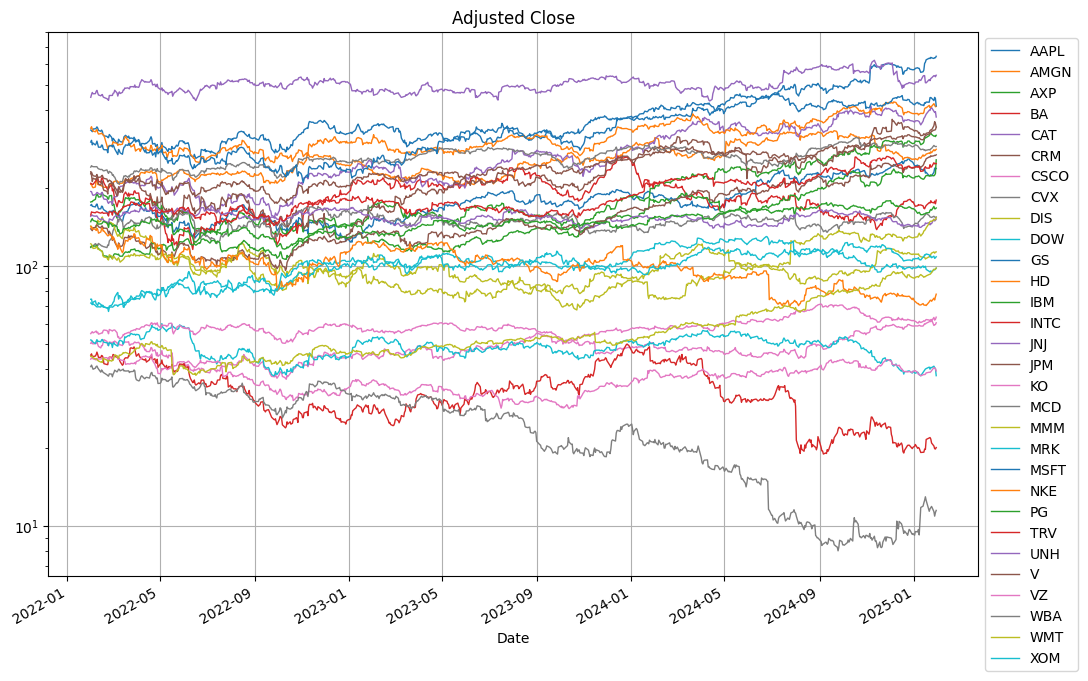

In [8]:
# list of stock symbols
tickers = [
    "AXP",
    "AAPL",
    "AMGN",
    "BA",
    "CAT",
    "CRM",
    "CSCO",
    "CVX",
    "DIS",
    "DOW",
    "GS",
    "HD",
    "IBM",
    "INTC",
    "JNJ",
    "JPM",
    "KO",
    "MCD",
    "MMM",
    "MRK",
    "MSFT",
    "NKE",
    "PG",
    "TRV",
    "UNH",
    "V",
    "VZ",
    "WBA",
    "WMT",
    "XOM",
]

# number of years
n_years = 3.0

# historical period
end_date = datetime.datetime(2025, 1, 31).date()  # datetime.datetime.today().date()
start_date = end_date - datetime.timedelta(round(n_years * 365))

assets = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

assets.fillna(method="bfill", inplace=True)
assets.fillna(method="ffill", inplace=True)

assets.plot(logy=True, figsize=(12, 8), grid=True, lw=1, title="Adjusted Close")
plt.legend(bbox_to_anchor=(1.0, 1.0))

## Daily return and Mean Absolute Deviation of historical asset prices

### Scaled asset prices

The historical prices are scaled to a value to have unit value at the start of the historical period. Scaling facilitates plotting and subsequent calculations while preserving arithmetic and logarithmic returns needed for analysis.

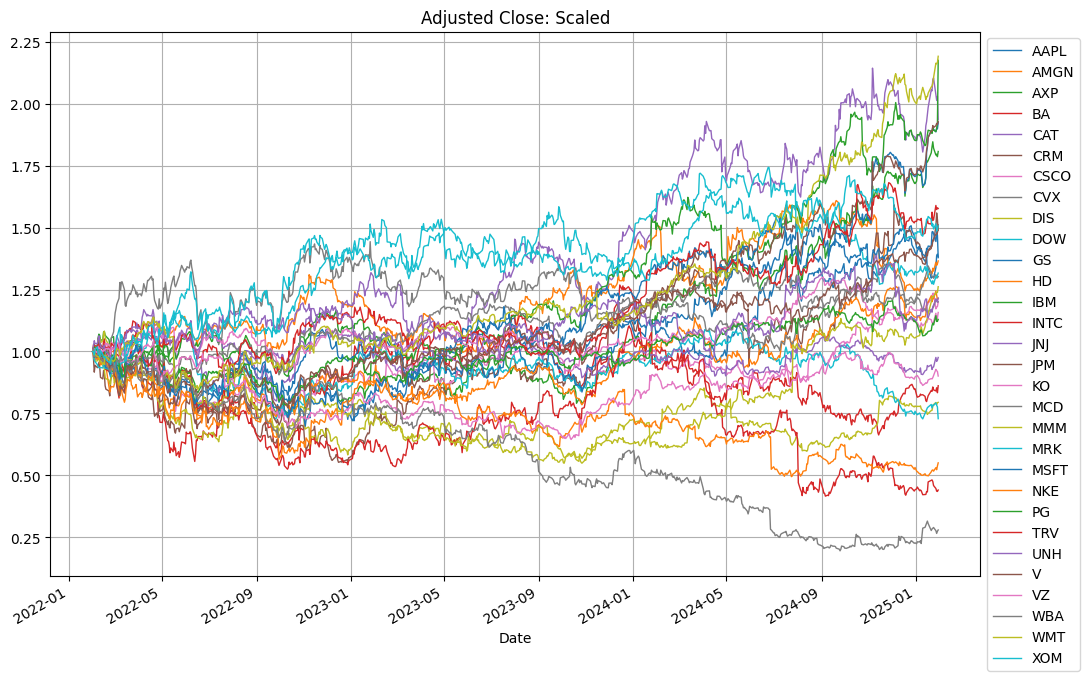

In [9]:
# scaled asset prices
assets_scaled = assets.div(assets.iloc[0])
assets_scaled.plot(figsize=(12, 8), grid=True, lw=1, title="Adjusted Close: Scaled")
plt.legend(bbox_to_anchor=(1.0, 1.0))

### Statistics of daily returns

The scaled price of asset $j$ on trading day $t$ is designated $S_{j, i}$. The daily return is computed as

$$r_{j, t} = \frac{S_{j, t} - S_{j, t-1}}{S_{j, t-1}}$$

where $t = 1, \dots, T$. The mean return for asset $j$ is

$$\bar{r}_j = \frac{1}{T} \sum_{t=1}^T r_{j, t}$$

The following cells compute and display the daily returns for all assets and displays as time series and histograms.

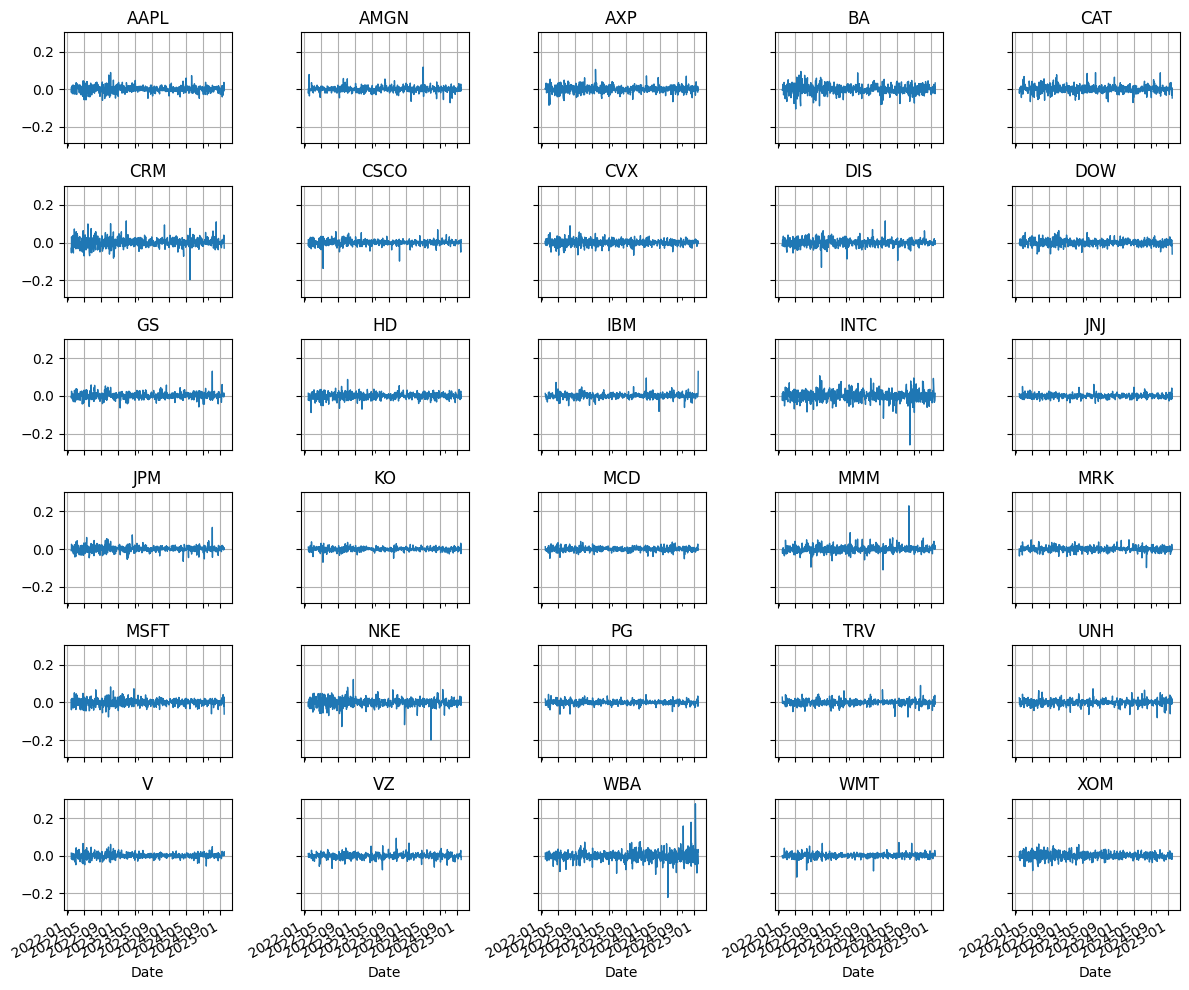

In [10]:
# daily returns
daily_returns = assets.diff()[1:] / assets.shift(1)[1:]

fig, ax = plt.subplots(6, 5, figsize=(12, 10), sharex=True, sharey=True)
for a, s in zip(ax.flatten(), sorted(daily_returns.columns)):
    daily_returns[s].plot(ax=a, lw=1, title=s, grid=True)

plt.tight_layout()

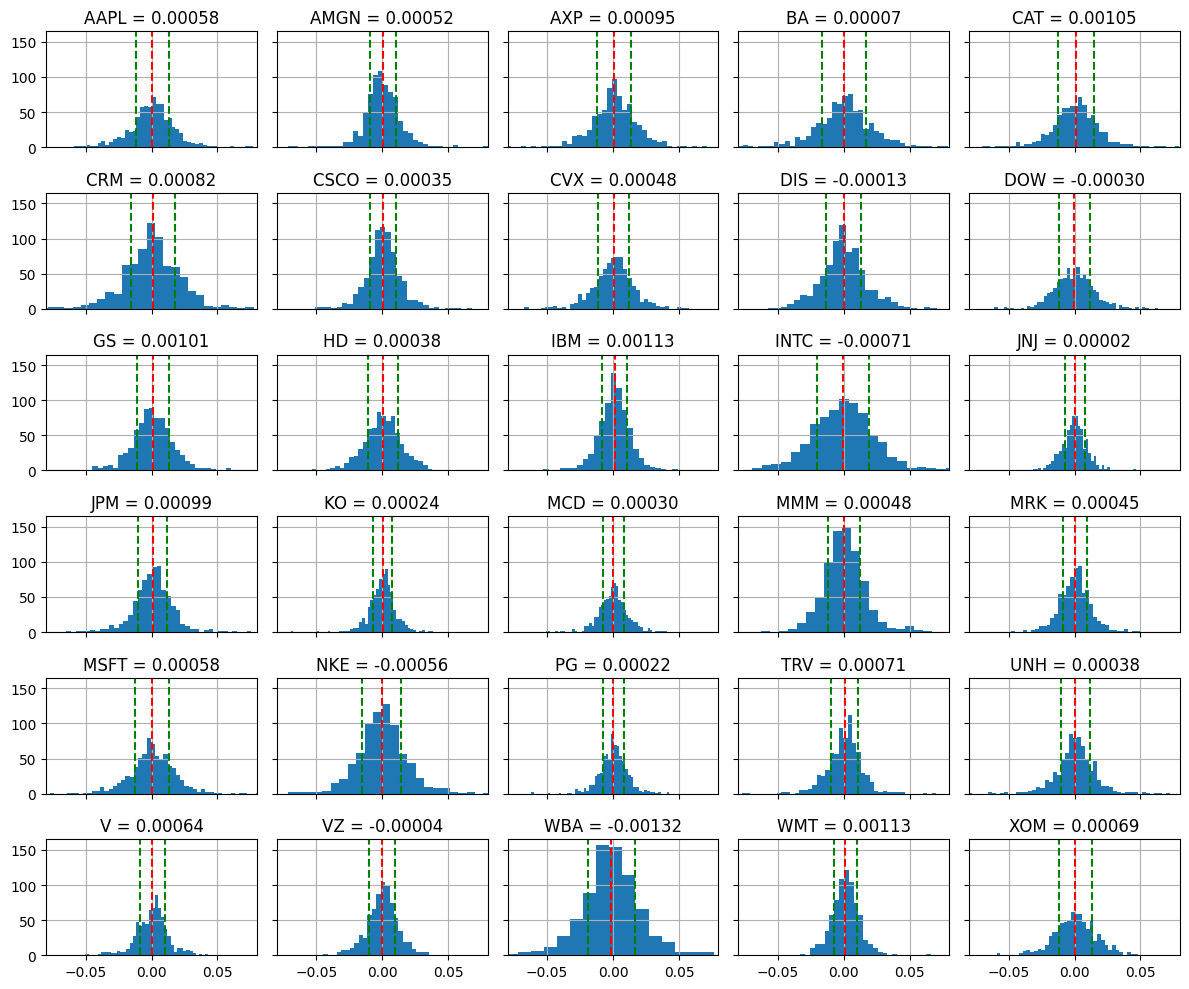

In [11]:
# distributions of returns

daily_returns = assets.diff()[1:] / assets.shift(1)[1:]

fig, ax = plt.subplots(6, 5, figsize=(12, 10), sharex=True, sharey=True)
ax = ax.flatten()

for a, s in zip(ax.flatten(), daily_returns.columns):
    daily_returns[s].hist(ax=a, lw=1, grid=True, bins=50)
    mean_return = daily_returns[s].mean()
    mean_absolute_deviation = abs((daily_returns[s] - mean_return)).mean()
    a.set_title(f"{s} = {mean_return:0.5f}")
    a.set_xlim(-0.08, 0.08)
    a.axvline(mean_return, color="r", linestyle="--")
    a.axvline(mean_return + mean_absolute_deviation, color="g", linestyle="--")
    a.axvline(mean_return - mean_absolute_deviation, color="g", linestyle="--")

plt.tight_layout()

### Mean Absolute Deviation

The mean absolute deviation (MAD) for asset $j$ is

$$\text{MAD}_j = \frac{1}{T} \sum_{t=1}^T | r_{j,t} - \bar{r}_j |$$

where $T$ is the period under consideration. The mean daily return and the mean absolute deviation in daily return are computed and plotted in the following cell. The side by side comparison provides a comparison of return vs volatility for individual assets.

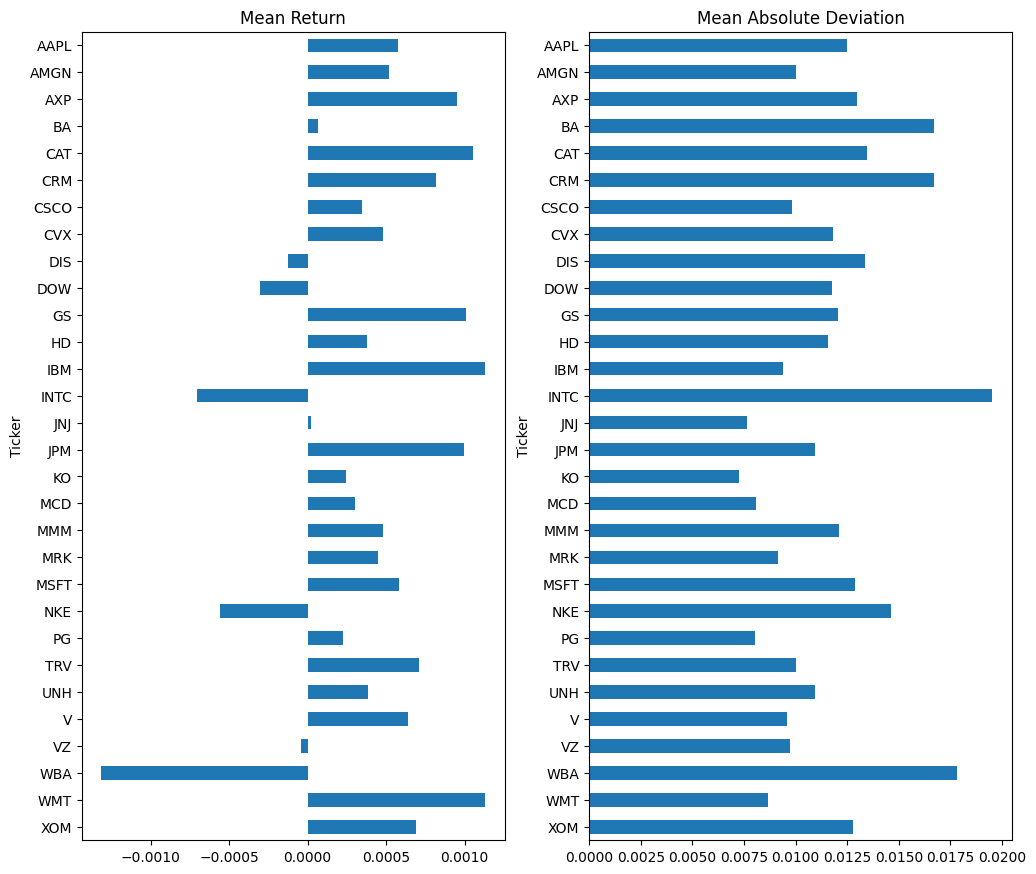

In [12]:
# bar charts of mean return and mean absolute deviation in returns

daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
mean_return = daily_returns.mean()
mean_absolute_deviation = abs(daily_returns - mean_return).mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 0.35 * len(daily_returns.columns)))
mean_return.plot(kind="barh", ax=ax[0], title="Mean Return")
ax[0].invert_yaxis()
mean_absolute_deviation.plot(kind="barh", ax=ax[1], title="Mean Absolute Deviation")
ax[1].invert_yaxis()

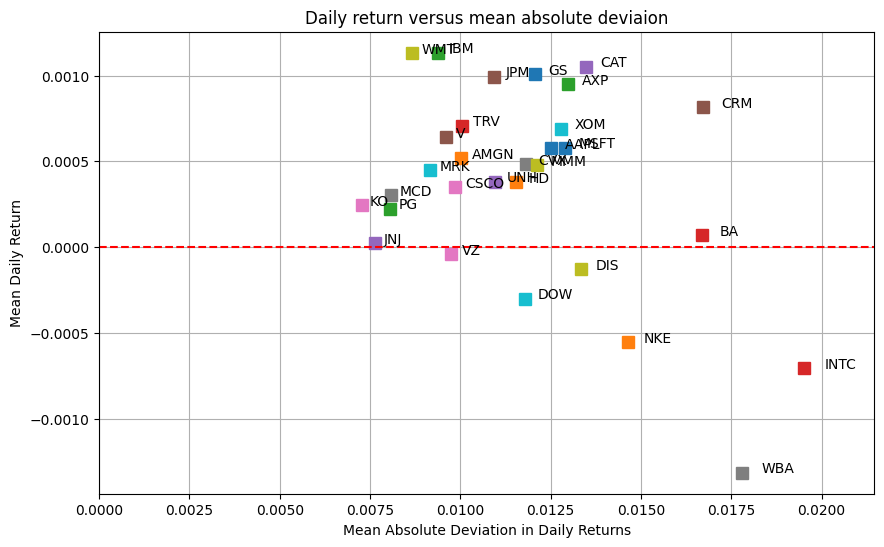

In [13]:
# plot return vs risk
daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
mean_return = daily_returns.mean()
mean_absolute_deviation = abs(daily_returns - mean_return).mean()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for s in assets.keys():
    ax.plot(mean_absolute_deviation[s], mean_return[s], "s", ms=8)
    ax.text(mean_absolute_deviation[s] * 1.03, mean_return[s], s)

ax.set_xlim(0, 1.1 * mean_absolute_deviation.max())
ax.axhline(0, color="r", linestyle="--")
ax.set_title("Daily return versus mean absolute deviaion")
ax.set_xlabel("Mean Absolute Deviation in Daily Returns")
ax.set_ylabel("Mean Daily Return")
ax.grid(True)

## Analysis of a portfolio of assets

### Return on a portfolio

Given a portfolio with value $W_t$ at time $t$, return on the portfolio at $t_{t +\delta t}$ is defined as

$$
\begin{align*}
r_{t + \delta t} & = \frac{W_{t + \delta t} - W_{t}}{W_{t}}
\end{align*}
$$

For the period from $[t, t+\delta t)$ we assume there are $n_{j,t}$ shares of asset $j$ with a starting value of $S_{j,t}$ per share. The initial and final values of the portfolio are then

$$
\begin{align*}
W_t & = \sum_{j=1}^J n_{j,t}S_{j,t} \\
W_{t+\delta t} & = \sum_{j=1}^J n_{j,t}S_{j,t + \delta t}
\end{align*}
$$

The return of the portfolio is given by

$$
\begin{align*}
r_{t+\delta t} & = \frac{W_{t + \delta t} - W_{t}}{W_{t}} \\
& = \frac{\sum_{j=1}^Jn_{j,t}S_{j,t+\delta t} - \sum_{j=1}^J n_{j,t}S_{j,t}}{W_{t}} \\
& = \frac{\sum_{j=1}^J n_{j,t}S_{j,t}r_{j, t+\delta t}}{W_{t}} \\
& = \sum_{j=1}^J \frac{n_{j,t}S_{j,t}}{W_{t}} r_{j, t+\delta t}
\end{align*}
$$

where $r_{j,t+\delta t}$ is the return on asset $j$ at time $t+\delta t$.

Defining $W_{j,t} = n_{j,t}S_{j,t}$ as the wealth invested in asset $j$ at time $t$, then $w_{j,t} = n_{j,t}S_{j,t}/W_{t}$ is the fraction of total wealth invested in asset $j$ at time $t$. The return on a portfolio of $J$ assets is then given by

$$
\begin{align*}
r_{t+\delta t} & = \sum_{j=1}^J w_{j,t} r_{j, t+\delta t}
\end{align*}
$$

on a single interval extending from $t$ to $t + \delta t$.

### Mean Absolute Deviation in portfolio returns

The return on a portfolio of $J$ assets over a period of $T$ intervals with weights $w_j$ for asset $j$ is given by

$$
\begin{align*}
\text{MAD} & =  \frac{1}{T} \sum_{t=1}^T \Big| \sum_{j=1}^J w_{j} (r_{t, j} - \bar{r}_j) \Big|,
\end{align*}
$$

where $r_{t, j}$ is the return on asset $j$ at time $t$, $\bar{r}_j$ is the mean return for asset $j$, and $w_j$ is the fraction of the total portfolio that is invested in asset $j$. Note that due to the use of absolute values, MAD for the portfolio is *not* the weighted sum of $\text{MAD}_j$ for individual assets

## MAD portfolio optimization

The portfolio optimization problem is to find an allocation of investments weights $w_j$ to minimize the portfolio measure of risk subject to constraints on required return and any other constraints an investor wishes to impose. Assume that we can make investment decisions at every trading day $t$ over a fixed time horizon ranging from $t=1,\dots,T$ and that there is a set of $J$ assets in which we can choose to invest."

$$
\begin{align*}
    \text{MAD} = \min \quad & \frac{1}{T} \sum_{t=1}^T \Big| \sum_{j=1}^J w_{j} (r_{t, j} - \bar{r}_j) \Big| \\
    \text{s.t.} \quad
    & \sum_{j=1}^J w_j \bar{r}_j  \geq R \\
    & \sum_{j=1}^J w_j  = 1 \\
    & w_j  \geq 0 & \forall \, j\in J\\
    & w_j  \leq w^{ub}_j & \forall \, j\in J.
\end{align*}
$$

where $R$ is the minimum required portfolio return. The lower bound $w_j \geq 0$ is a "no short sales" constraint. The upper bound $w_j \leq w^{ub}_j$ enforces a required level of diversification in the portfolio.

Defining two sets of auxiliary variables $u_t \geq 0$ and $v_t \geq 0$ for every $t=1,\dots,T$, leads to a reformulation of the problem as a linear optimization:

$$
\begin{align*}
    \text{MAD} = \min \quad & \frac{1}{T} \sum_{t=1}^T (u_t + v_t) \\
    \text{s.t.} \quad
    & u_t - v_t  = \sum_{j=1}^J w_j(r_{t,j} - \bar{r}_j) & \forall t\in 1, \dots, T \\
    & \sum_{j=1}^J w_j \bar{r}_j  \geq R \\
    & \sum_{j=1}^J w_j = 1 \\
    & w_j  \geq 0 & \forall \, j\in J\\
    & w_j  \leq w^{ub}_j & \forall \, j\in J\\
    & u_t, v_t \geq 0 &t = 1, \dots, T.
\end{align*}
$$


## AMPL model

In [14]:
%%writefile mad_portfolio.mod

param R default 0;
param w_lb default 0;
param w_ub default 1;

set ASSETS;
set TIME;

param daily_returns{TIME, ASSETS};
param mean_return{ASSETS};

var w{ASSETS};
var u{TIME} >= 0;
var v{TIME} >= 0;

minimize MAD: sum{t in TIME}(u[t] + v[t]) / card(TIME);

s.t. portfolio_returns {t in TIME}:
    u[t] - v[t] == sum{j in ASSETS}(w[j] * (daily_returns[t, j] - mean_return[j]));

s.t. sum_of_weights: sum{j in ASSETS} w[j] == 1;

s.t. mean_portfolio_return: sum{j in ASSETS}(w[j] * mean_return[j]) >= R;

s.t. no_short {j in ASSETS}: w[j] >= w_lb;

s.t. diversify {j in ASSETS}: w[j] <= w_ub;

Writing mad_portfolio.mod


<ipython-input-15-00c4d12ec20d>:5: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  daily_returns["Date"] = daily_returns.index.format()


HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.007269380462
857 simplex iterations
0 barrier iterations
Weight lower bound                0.000
Weight upper bound                0.200
Fraction of portfolio invested     1.000
Required portfolio daily return    0.00100
Portfolio mean daily return        0.00100
Portfolio mean absolute deviation  0.00727


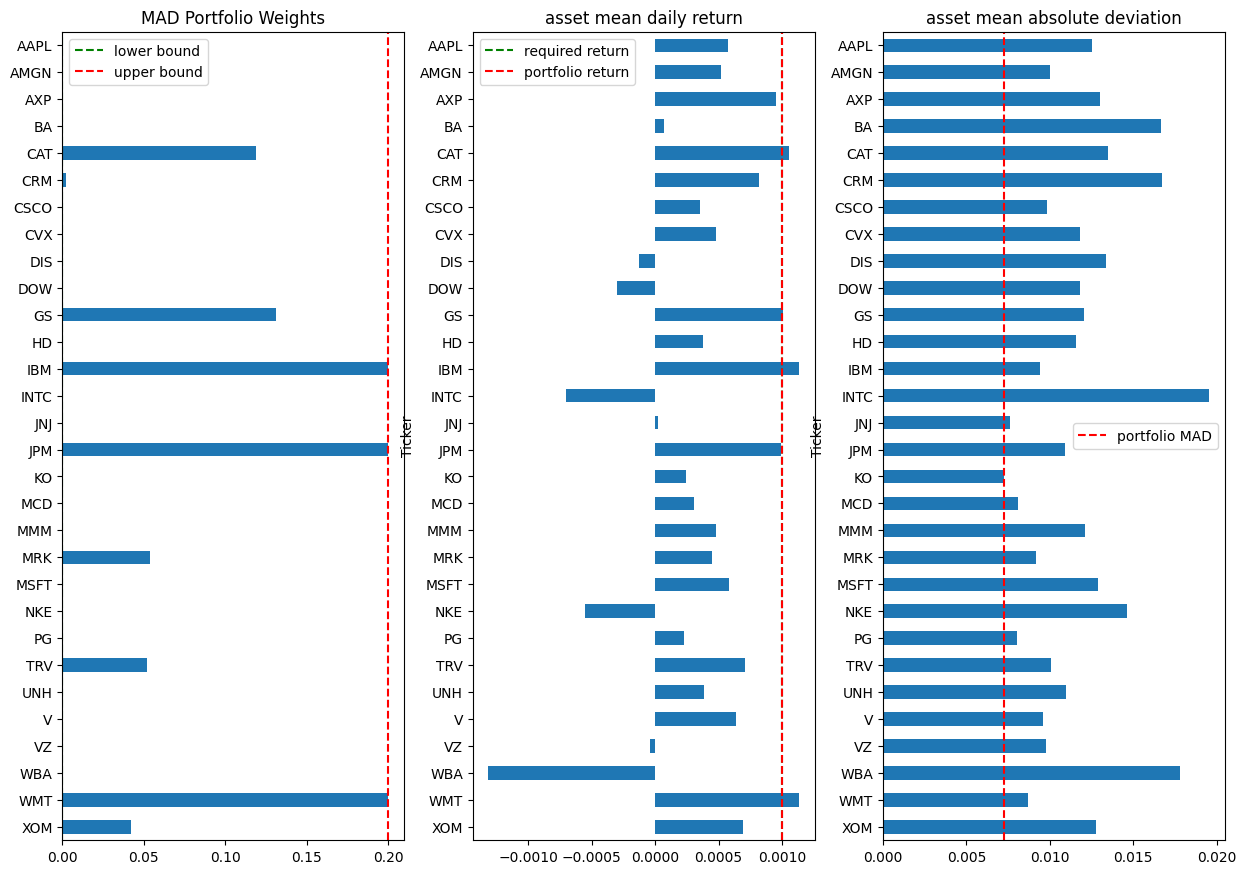

In [15]:
def mad_portfolio(assets):
    daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
    mean_return = daily_returns.mean()

    daily_returns["Date"] = daily_returns.index.format()
    daily_returns.set_index("Date", inplace=True)

    ampl = AMPL()
    ampl.read("mad_portfolio.mod")

    ampl.set["ASSETS"] = list(assets.columns)
    ampl.set["TIME"] = daily_returns.index.values

    ampl.param["daily_returns"] = daily_returns
    ampl.param["mean_return"] = mean_return

    return ampl


def mad_visualization(assets, m):
    mean_portfolio_return = m.get_value("sum{j in ASSETS}(w[j] * mean_return[j])")

    print(f"Weight lower bound                {m.param['w_lb'].value():0.3f}")
    print(f"Weight upper bound                {m.param['w_ub'].value():0.3f}")
    print(
        f"Fraction of portfolio invested     {m.get_value('sum{j in ASSETS} w[j]'):0.3f}"
    )
    print(f"Required portfolio daily return    {m.param['R'].value():0.5f}")
    print(f"Portfolio mean daily return        {mean_portfolio_return:0.5f}")
    print(f"Portfolio mean absolute deviation  {m.obj['MAD'].value():0.5f}")

    daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
    mean_return = daily_returns.mean()
    mean_absolute_deviation = abs(daily_returns - mean_return).mean()
    mad_portfolio_weights = m.var["w"].to_pandas()

    fig, ax = plt.subplots(1, 3, figsize=(15, 0.35 * len(daily_returns.columns)))
    mad_portfolio_weights.plot(kind="barh", ax=ax[0], title="MAD Portfolio Weights")
    ax[0].invert_yaxis()
    ax[0].axvline(m.param["w_lb"].value(), ls="--", color="g")
    ax[0].axvline(m.param["w_ub"].value(), ls="--", color="r")
    ax[0].legend(["lower bound", "upper bound"])

    mean_return.plot(kind="barh", ax=ax[1], title="asset mean daily return")
    ax[1].axvline(m.param["R"].value(), ls="--", color="g")

    ax[1].axvline(mean_portfolio_return, ls="--", color="r")
    ax[1].invert_yaxis()
    ax[1].legend(["required return", "portfolio return"])

    mean_absolute_deviation.plot(
        kind="barh", ax=ax[2], title="asset mean absolute deviation"
    )
    ax[2].axvline(m.obj["MAD"].value(), ls="--", color="r")
    ax[2].legend(["portfolio MAD"])
    ax[2].invert_yaxis()


m = mad_portfolio(assets)
m.param["w_lb"] = 0
m.param["w_ub"] = 0.2
m.param["R"] = 0.001
m.solve(solver=SOLVER)
assert m.solve_result == "solved", m.solve_result
mad_visualization(assets, m)

## MAD risk versus return

The portfolio optimization problem has been formulated as the minimization of a risk measure, MAD, subject to a lower bound $R$ on mean portfolio return. Increasing the required return for the portfolio therefore comes at the cost of tolerating a higher level of risk. Finding the optimal trade off between risk and return is a central aspect of any investment strategy.

The following cell creates a plot of the risk/return trade off by solving the MAD portfolio optimization problem for increasing values of required return $R$. This should be compared to the similar construction commonly used in presentations of the portfolio optimization problem due to Markowitz.

<ipython-input-15-00c4d12ec20d>:5: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  daily_returns["Date"] = daily_returns.index.format()


HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
889 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.005384573911
18 simplex iterations
0 barrier

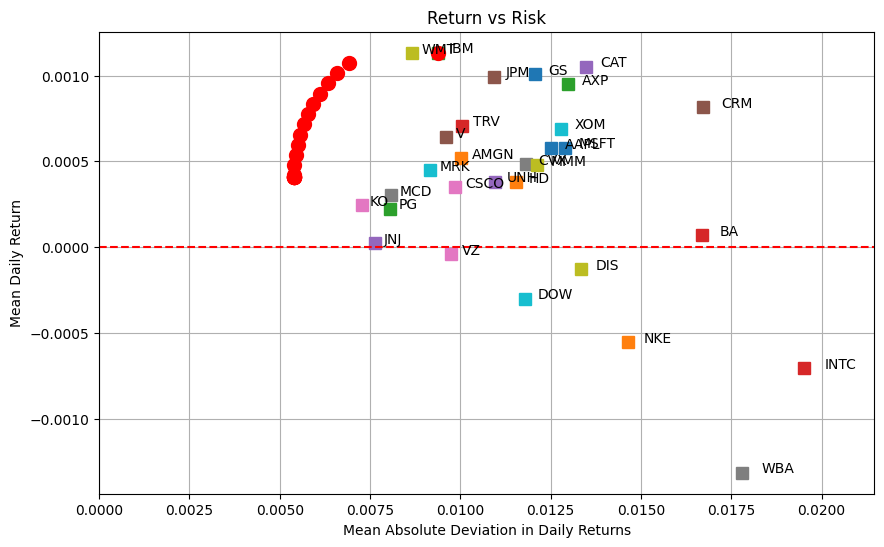

In [16]:
# plot return vs risk
daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
mean_return = daily_returns.mean()
mean_absolute_deviation = abs(daily_returns - mean_return).mean()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for s in assets.keys():
    ax.plot(mean_absolute_deviation[s], mean_return[s], "s", ms=8)
    ax.text(mean_absolute_deviation[s] * 1.03, mean_return[s], s)

ax.set_xlim(0, 1.1 * max(mean_absolute_deviation))
ax.axhline(0, color="r", linestyle="--")
ax.set_title("Return vs Risk")
ax.set_xlabel("Mean Absolute Deviation in Daily Returns")
ax.set_ylabel("Mean Daily Return")
ax.grid(True)

m = mad_portfolio(assets)
for R in np.linspace(0, mean_return.max(), 20):
    m.param["R"] = R
    m.solve(solver=SOLVER)
    assert m.solve_result == "solved", m.solve_result
    mad_portfolio_weights = m.var["w"].to_pandas()
    portfolio_returns = daily_returns.dot(mad_portfolio_weights)
    portfolio_mean_return = portfolio_returns.mean()
    portfolio_mean_absolute_deviation = abs(
        portfolio_returns - portfolio_mean_return
    ).mean()
    ax.plot(portfolio_mean_absolute_deviation, portfolio_mean_return, "ro", ms=10)

## Addition of a Risk-free Asset

The option of a holding a risk-free asset as a component of investment can substantially reduce financial risk. The risk-free asset is designated as $j=0$ with a fixed return $\bar{r}_0$. The fraction invested in asset $j=0$ will be $w_0 = 1 - \sum_{j=1}^J w_j$. The optimization model becomes

$$
\begin{align*}
\text{MAD} = \min \quad & \frac{1}{T} \sum_{t=1}^T \Big| \sum_{j=1}^J w_{j} (r_{t, j} - \bar{r}_j) \Big| \\
\text{s.t.} \quad
    & \sum_{j=1}^J w_j (\bar{r}_j - \bar{r}_0) \geq R - \bar{r}_0 \\
    & \sum_{j=1}^J w_j \leq 1 \\
    & w_j \geq 0 & \forall j\in 1,\dots, J \\
    & w_j \leq w^{ub}_j & \forall j\in 1, \dots, J \\
\end{align*}
$$

where $R$ is the minimum required portfolio return. The lower bound $w_j \geq 0$ is a "no short sales" constraint. The upper bound $w_j \leq w^{ub}_j$ enforces a required level of diversification in the portfolio.

Defining two sets of auxiliary variables $u_t \geq 0$ and $v_t \geq 0$ for every $t=1,\dots,T$, leads to a reformulation of the problem as an LO:

$$
\begin{align*}
\text{MAD} = \min \quad & \frac{1}{T} \sum_{t=1}^T (u_t + v_t) \\
\text{s.t.} \quad
    & u_t - v_t = \sum_{j=1}^J w_j(r_{t,j} - \bar{r}_j) & \forall t\in 1, \dots, T \\
    & \sum_{j=1}^J w_j (\bar{r}_j - \bar{r}_0) \geq R - \bar{r}_0 \\
    & \sum_{j=1}^J w_j \leq 1 \\
    & w_j \geq 0 & \forall j\in 1,\dots, J \\
    & w_j \leq w^{ub}_j & \forall j\in 1, \dots, J \\
    & u_t, v_t \geq 0 & \forall t\in 1, \dots, T.
\end{align*}
$$


In [17]:
%%writefile mad_portfolio_cash.mod

param R default 0;
param rf default 0;
param w_lb default 0;
param w_ub default 1;

set ASSETS;
set TIME;

param daily_returns{TIME, ASSETS};
param mean_return{ASSETS};

var w{ASSETS};
var u{TIME} >= 0;
var v{TIME} >= 0;

minimize MAD: sum{t in TIME}(u[t] + v[t]) / card(TIME);

s.t. portfolio_returns {t in TIME}:
    u[t] - v[t] == sum{j in ASSETS}(w[j] * (daily_returns[t, j] - mean_return[j]));

s.t. sum_of_weights: sum{j in ASSETS} w[j] <= 1;

s.t. mean_portfolio_return: sum{j in ASSETS}(w[j] * (mean_return[j] - rf)) >= R - rf;

s.t. no_short {j in ASSETS}: w[j] >= w_lb;

s.t. diversify {j in ASSETS}: w[j] <= w_ub;

Writing mad_portfolio_cash.mod


<ipython-input-18-c2649f67a057>:5: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  daily_returns["Date"] = daily_returns.index.format()


HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.007269380462
857 simplex iterations
0 barrier iterations
Weight lower bound                0.000
Weight upper bound                0.200
Fraction of portfolio invested     1.000
Required portfolio daily return    0.00100
Portfolio mean daily return        0.00100
Portfolio mean absolute deviation  0.00727


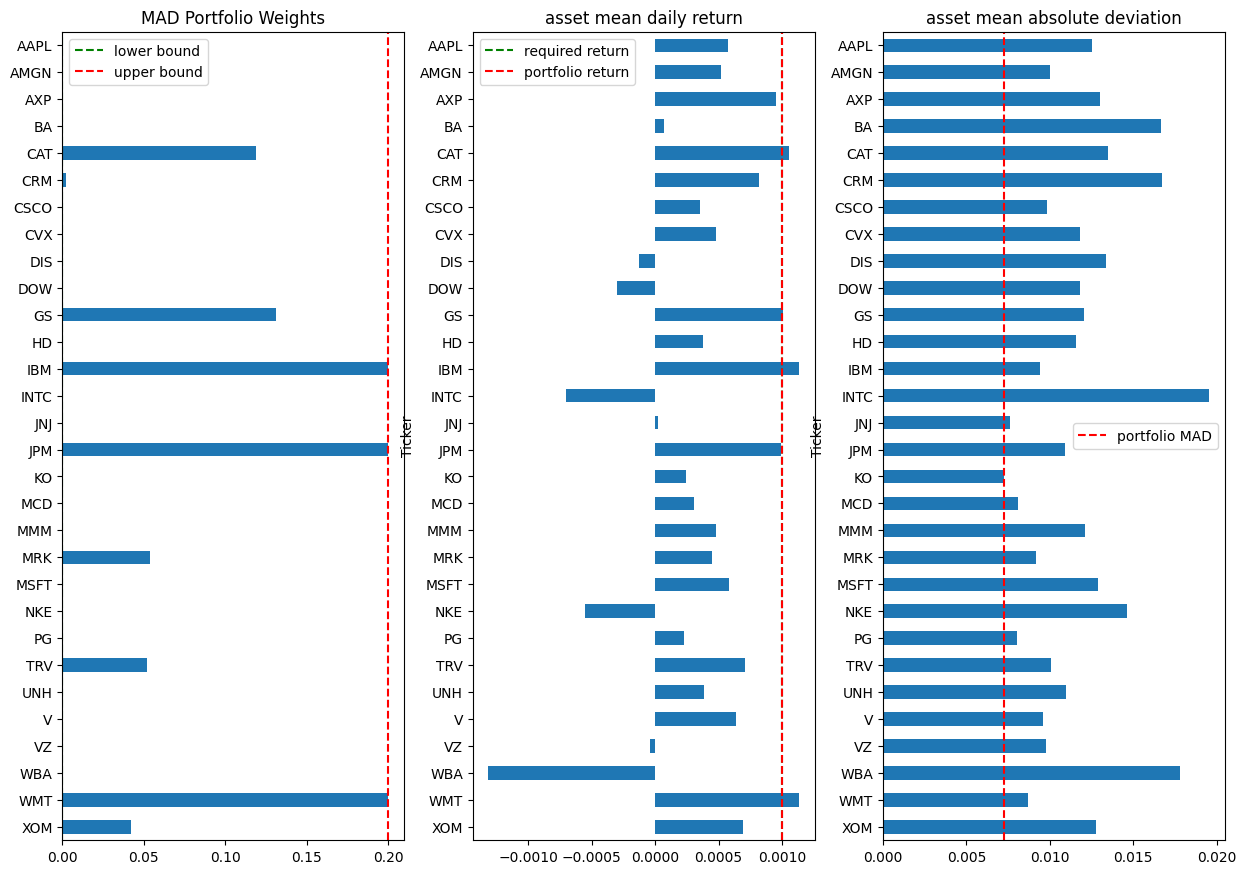

In [18]:
def mad_portfolio_cash(assets):
    daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
    mean_return = daily_returns.mean()

    daily_returns["Date"] = daily_returns.index.format()
    daily_returns.set_index("Date", inplace=True)

    ampl = AMPL()
    ampl.read("mad_portfolio_cash.mod")

    ampl.set["ASSETS"] = list(assets.columns)
    ampl.set["TIME"] = daily_returns.index.values

    ampl.param["daily_returns"] = daily_returns
    ampl.param["mean_return"] = mean_return

    return ampl


m = mad_portfolio_cash(assets)
m.param["w_lb"] = 0
m.param["w_ub"] = 0.2
m.param["R"] = 0.001
m.solve(solver=SOLVER)
assert m.solve_result == "solved", m.solve_result
mad_visualization(assets, m)

## MAD risk versus return with a risk-free asset

As above, it is instructive to plot the MAD risk versus required return $R$. The result is similar, but not exactly the same, as  the standard presentation from modern portfolio theory (MPT) for efficient frontier of investing, and the capital market line. A careful look at the the plot below shows minor difference at very high levels of return and risk that departs from the MPT analysis.

<ipython-input-15-00c4d12ec20d>:5: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  daily_returns["Date"] = daily_returns.index.format()
<ipython-input-18-c2649f67a057>:5: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  daily_returns["Date"] = daily_returns.index.format()


HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
889 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.00538400317
0 simplex iterations
0 barrier iterations
HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 0.005384573911
18 simplex iterations
0 barrier

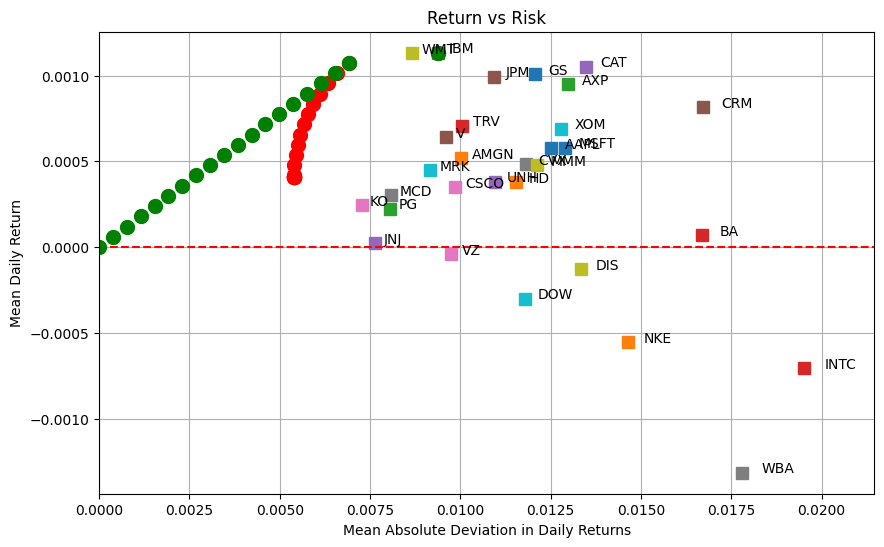

In [19]:
# plot return vs risk
daily_returns = assets.diff()[1:] / assets.shift(1)[1:]
mean_return = daily_returns.mean()
mean_absolute_deviation = abs(daily_returns - mean_return).mean()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for s in assets.keys():
    ax.plot(mean_absolute_deviation[s], mean_return[s], "s", ms=8)
    ax.text(mean_absolute_deviation[s] * 1.03, mean_return[s], s)

ax.set_xlim(0, 1.1 * max(mean_absolute_deviation))
ax.axhline(0, color="r", linestyle="--")
ax.set_title("Return vs Risk")
ax.set_xlabel("Mean Absolute Deviation in Daily Returns")
ax.set_ylabel("Mean Daily Return")
ax.grid(True)

for color, m in zip(["ro", "go"], [mad_portfolio(assets), mad_portfolio_cash(assets)]):
    for R in np.linspace(0, mean_return.max(), 20):
        m.param["R"] = R
        m.solve(solver=SOLVER)
        assert m.solve_result == "solved", m.solve_result
        mad_portfolio_weights = m.var["w"].to_pandas()
        portfolio_returns = daily_returns.dot(mad_portfolio_weights)
        portfolio_mean_return = portfolio_returns.mean()
        portfolio_mean_absolute_deviation = abs(
            portfolio_returns - portfolio_mean_return
        ).mean()
        ax.plot(portfolio_mean_absolute_deviation, portfolio_mean_return, color, ms=10)